# simple Ridge Regression

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score

In [17]:
X,y = make_regression(n_features=1,n_samples=100,n_informative=1,n_targets=1,noise=10,random_state=42)

In [4]:
X.shape

(100, 1)

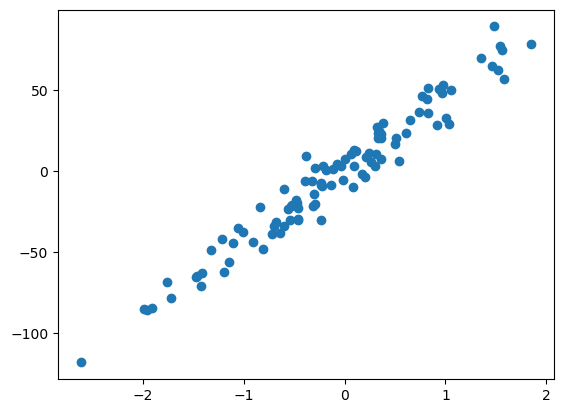

In [29]:
plt.scatter(X,y)
plt.show()

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
rg = Ridge(alpha=0.2)

In [20]:
rg.fit(X_train,y_train)

,alpha,0.2
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
y_pred = rg.predict(X_test)

In [22]:
r2_score(y_test,y_pred)

0.9372576341945977

In [33]:
rg.coef_

array([44.10933994])

In [34]:
rg.intercept_

0.08187416455700003

In [25]:
lr = LinearRegression()

In [26]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = lr.predict(X_test)

In [28]:
r2_score(y_test,y_pred)

0.9374151607623286

In [37]:
class ridge_reg:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.b = None
        self.m = None

    def fit(self,X_train,y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + (y_train[i]-y_train.mean())*(X_train[i]-X_train.mean())
            den = den + (X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())
        self.m = num/(den+self.alpha)
        self.b = y_train.mean() - self.m*X_train.mean()

        #print(self.m,self.b)

    def predict(self,X_test):
        return self.m * X_test + self.b

In [38]:
reg = ridge_reg(alpha=0)

In [39]:
reg.fit(X_train,y_train)

In [41]:
y_pred = reg.predict(X_test)

In [42]:
r2_score(y_test,y_pred)

0.9374151607623286

In [47]:
reg1 = ridge_reg(alpha=20)
reg1.fit(X_train,y_train)

reg2 = ridge_reg(alpha=40)
reg2.fit(X_train,y_train)

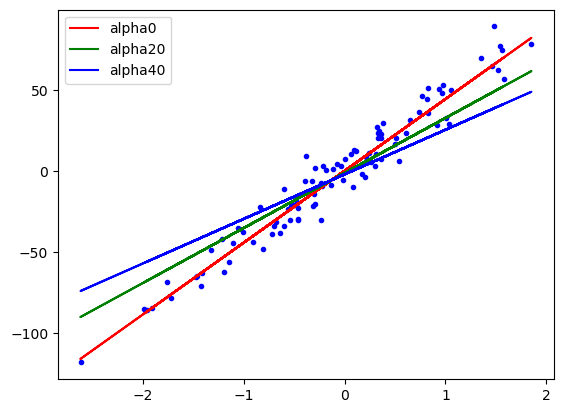

In [50]:
plt.plot(X,y,'b.')
plt.plot(X,reg.predict(X),c='r',label='alpha0')
plt.plot(X,reg1.predict(X),c='g',label='alpha20')
plt.plot(X,reg2.predict(X),c='b',label='alpha40')
plt.legend()
plt.show()

# Multiple Ridge Regression

In [52]:
X,y = load_diabetes(return_X_y=True)

In [53]:
X.shape

(442, 10)

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
X_train.shape

(353, 10)

In [56]:
rg = Ridge(alpha=1)

In [57]:
rg.fit(X_train,y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [58]:
y_pred = rg.predict(X_test)

In [59]:
r2_score(y_test,y_pred)

0.41915292635986545

In [60]:
rg.coef_

array([  45.36737726,  -76.66608563,  291.33883165,  198.99581745,
         -0.53030959,  -28.57704987, -144.51190505,  119.26006559,
        230.22160832,  112.14983004])

In [61]:
rg.intercept_

152.241675211113

In [72]:
class ridge_reg:
    def __init__(self,alpha=0):
        self.alpha=alpha
        self.intercept_ = None
        self.coef_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T,X_train)+self.alpha*I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

        #print(self.intercept_,self.coef_)

In [73]:
reg = ridge_reg(alpha=0)

In [74]:
reg.fit(X_train,y_train)

151.34560453986 [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
